# 11 — Model Explainability


In [1]:
#Imports

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay,
)
from sklearn.tree import (
    export_text,
    plot_tree,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

ROOT = Path.cwd().parent
FEATURE_DIR = ROOT / "artifacts" / "features"
MODEL_DIR = ROOT / "artifacts" / "models"
EXPLAIN_DIR = ROOT / "artifacts" / "explainability"
CHART_DIR = ROOT / "artifacts" / "charts"

EXPLAIN_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

print("SHAP version:", shap.__version__)


SHAP version: 0.52.0


In [2]:
# Load Models and Data

base_model = joblib.load(
    MODEL_DIR / "final_selected_model.joblib"
)

calibrated_model = joblib.load(
    MODEL_DIR / "final_calibrated_model.joblib"
)

X_train = pd.read_parquet(
    FEATURE_DIR / "X_train_raw.parquet"
)

X_test = pd.read_parquet(
    FEATURE_DIR / "X_test_raw.parquet"
)

with open(
    FEATURE_DIR / "feature_metadata.json",
    "r",
    encoding="utf-8",
) as file:
    feature_metadata = json.load(file)

TARGET_COLUMN = feature_metadata["target_column"]

y_train = pd.read_parquet(
    FEATURE_DIR / "y_train.parquet"
)[TARGET_COLUMN]

y_test = pd.read_parquet(
    FEATURE_DIR / "y_test.parquet"
)[TARGET_COLUMN]

print("Base model:", type(base_model).__name__)
print("Calibrated model:", type(calibrated_model).__name__)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Base model: Pipeline
Calibrated model: CalibratedClassifierCV
Training shape: (400, 5)
Testing shape: (100, 5)


In [3]:
# Decision Tree Extraction

preprocessor = base_model.named_steps[
    "preprocessor"
]

tree_model = base_model.named_steps[
    "model"
]

print("Underlying estimator:", type(tree_model).__name__)
print("Tree depth:", tree_model.get_depth())
print("Tree leaves:", tree_model.get_n_leaves())

Underlying estimator: DecisionTreeClassifier
Tree depth: 8
Tree leaves: 40


In [4]:
# Feature Transformation

X_train_transformed = preprocessor.transform(
    X_train
)

X_test_transformed = preprocessor.transform(
    X_test
)

if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = (
        X_train_transformed.toarray()
    )

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = (
        X_test_transformed.toarray()
    )

transformed_feature_names = (
    preprocessor.get_feature_names_out()
)

X_train_explain = pd.DataFrame(
    X_train_transformed,
    columns=transformed_feature_names,
)

X_test_explain = pd.DataFrame(
    X_test_transformed,
    columns=transformed_feature_names,
)

print("Explanation feature shape:", X_test_explain.shape)
print("Features:")

for feature_name in transformed_feature_names:
    print(feature_name)

Explanation feature shape: (100, 8)
Features:
numeric__age
numeric__income
numeric__visits
numeric__satisfaction
categorical__region_East
categorical__region_North
categorical__region_South
categorical__region_West


In [5]:
# Tree-native Feature Importance

tree_importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "tree_importance":
        tree_model.feature_importances_,
})

tree_importance_df = (
    tree_importance_df.sort_values(
        "tree_importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(tree_importance_df.round(6))

,feature,tree_importance
0,numeric__satisfaction,0.348198
1,numeric__income,0.297599
2,numeric__visits,0.282287
3,numeric__age,0.041267
4,categorical__region_East,0.019698
5,categorical__region_South,0.007660
6,categorical__region_North,0.003291
7,categorical__region_West,0.000000


In [6]:
# Create Shap Explainer

tree_explainer = shap.TreeExplainer(
    tree_model
)

raw_shap_values = (
    tree_explainer.shap_values(
        X_test_explain
    )
)

expected_value = tree_explainer.expected_value

In [7]:
# Handle SHAP Formats

if isinstance(raw_shap_values, list):
    if len(raw_shap_values) == 2:
        class_one_shap_values = (
            raw_shap_values[1]
        )
    else:
        class_one_shap_values = (
            raw_shap_values[0]
        )

elif (
    isinstance(raw_shap_values, np.ndarray)
    and raw_shap_values.ndim == 3
):
    class_one_shap_values = (
        raw_shap_values[:, :, 1]
    )

else:
    class_one_shap_values = np.asarray(
        raw_shap_values
    )


if isinstance(expected_value, (list, tuple)):
    class_one_expected_value = float(
        expected_value[1]
        if len(expected_value) > 1
        else expected_value[0]
    )

elif (
    isinstance(expected_value, np.ndarray)
    and expected_value.size > 1
):
    class_one_expected_value = float(
        expected_value.ravel()[1]
    )

else:
    class_one_expected_value = float(
        np.asarray(expected_value).ravel()[0]
    )


print(
    "SHAP values shape:",
    class_one_shap_values.shape,
)

print(
    "Expected value for class 1:",
    class_one_expected_value,
)

SHAP values shape: (100, 8)
Expected value for class 1: 0.5


In [8]:
# Global SHAP Importance

global_shap_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "mean_absolute_shap": np.abs(
        class_one_shap_values
    ).mean(axis=0),
    "mean_signed_shap":
        class_one_shap_values.mean(axis=0),
})

global_shap_df = global_shap_df.sort_values(
    "mean_absolute_shap",
    ascending=False,
).reset_index(drop=True)

display(global_shap_df.round(6))

,feature,mean_absolute_shap,mean_signed_shap
0,numeric__visits,0.243420,0.016866
1,numeric__income,0.189263,0.018204
2,numeric__satisfaction,0.181453,0.022128
3,numeric__age,0.024371,0.015246
4,categorical__region_South,0.010148,0.005754
5,categorical__region_East,0.008336,0.000425
6,categorical__region_North,0.005778,0.003786
7,categorical__region_West,0.000000,0.000000


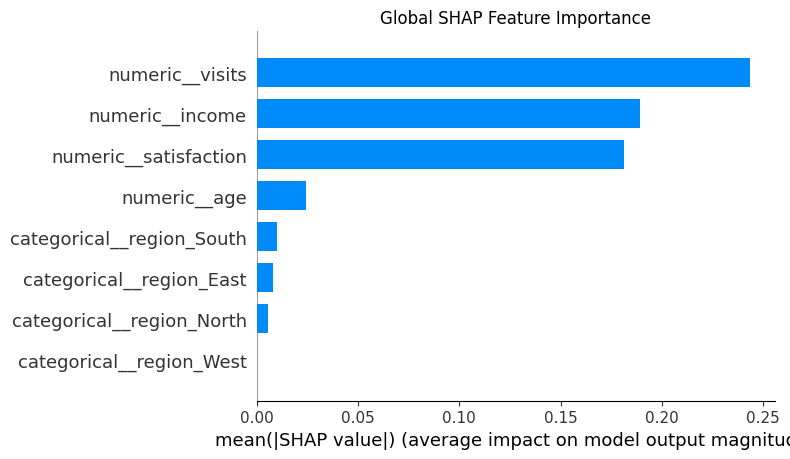

In [9]:
# SHAP BAr Chart

plt.figure(figsize=(10, 6))

shap.summary_plot(
    class_one_shap_values,
    X_test_explain,
    plot_type="bar",
    show=False,
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "shap_global_importance.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

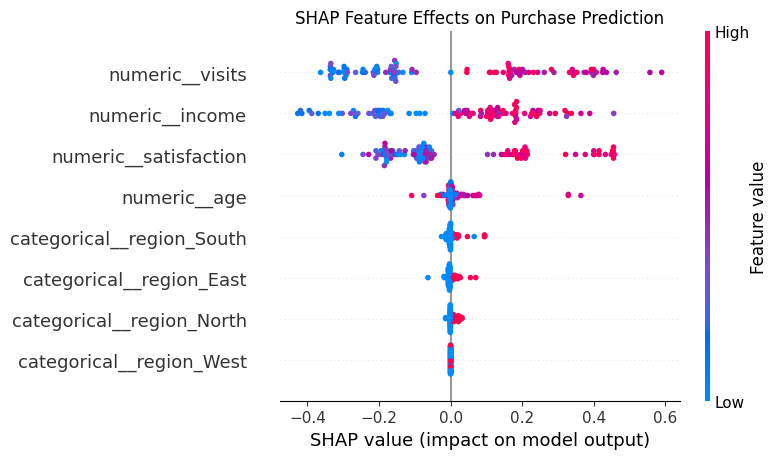

In [10]:
# Shap Beeswarm Plot

plt.figure(figsize=(10, 6))

shap.summary_plot(
    class_one_shap_values,
    X_test_explain,
    show=False,
)

plt.title(
    "SHAP Feature Effects on Purchase Prediction"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "shap_beeswarm.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [11]:
# Aggregate one hot features

def original_feature_name(
    transformed_name,
):
    cleaned_name = transformed_name.split(
        "__",
        1,
    )[-1]

    for original_column in X_train.columns:
        if (
            cleaned_name == original_column
            or cleaned_name.startswith(
                f"{original_column}_"
            )
        ):
            return original_column

    return cleaned_name


grouped_shap_df = global_shap_df.copy()

grouped_shap_df["original_feature"] = (
    grouped_shap_df["feature"].apply(
        original_feature_name
    )
)

grouped_shap_df = (
    grouped_shap_df.groupby(
        "original_feature",
        as_index=False,
    )["mean_absolute_shap"]
    .sum()
    .sort_values(
        "mean_absolute_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(grouped_shap_df.round(6))

,original_feature,mean_absolute_shap
0,visits,0.243420
1,income,0.189263
2,satisfaction,0.181453
3,age,0.024371
4,region,0.024261


In [12]:
# Permutation Importance

permutation_result = permutation_importance(
    estimator=calibrated_model,
    X=X_test,
    y=y_test,
    scoring="f1_macro",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean":
        permutation_result.importances_mean,
    "importance_std":
        permutation_result.importances_std,
})

permutation_importance_df = (
    permutation_importance_df.sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    permutation_importance_df.round(6)
)

,feature,importance_mean,importance_std
0,satisfaction,0.130736,0.036708
1,income,0.125833,0.030226
2,visits,0.125353,0.024449
3,age,0.014729,0.009086
4,region,0.008347,0.012680


In [13]:
# Explain one individual prediction

ROW_TO_EXPLAIN = 0

raw_customer = X_test.iloc[
    [ROW_TO_EXPLAIN]
]

actual_value = y_test.iloc[
    ROW_TO_EXPLAIN
]

base_prediction = base_model.predict(
    raw_customer
)[0]

calibrated_prediction = (
    calibrated_model.predict(
        raw_customer
    )[0]
)

calibrated_probability = (
    calibrated_model.predict_proba(
        raw_customer
    )[0, 1]
)

local_shap_values = (
    class_one_shap_values[
        ROW_TO_EXPLAIN
    ]
)

local_explanation_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "feature_value":
        X_test_explain.iloc[
            ROW_TO_EXPLAIN
        ].values,
    "shap_value":
        local_shap_values,
})

local_explanation_df[
    "absolute_shap"
] = local_explanation_df[
    "shap_value"
].abs()

local_explanation_df = (
    local_explanation_df.sort_values(
        "absolute_shap",
        ascending=False,
    )
)

print("Original input:")

display(raw_customer)

print("Actual value:", actual_value)
print("Base prediction:", base_prediction)
print(
    "Calibrated prediction:",
    calibrated_prediction,
)
print(
    "Calibrated purchase probability:",
    round(calibrated_probability, 4),
)

display(
    local_explanation_df.round(6)
)

Original input:


,age,income,region,visits,satisfaction
0,44,24497,South,11,4.1


Actual value: 1
Base prediction: 1
Calibrated prediction: 1
Calibrated purchase probability: 0.8824


,feature,feature_value,shap_value,absolute_shap
2,numeric__visits,0.098320,0.402909,0.402909
3,numeric__satisfaction,0.884347,0.159574,0.159574
1,numeric__income,-1.596883,-0.086033,0.086033
0,numeric__age,-0.033284,0.019709,0.019709
6,categorical__region_South,1.000000,0.006725,0.006725
4,categorical__region_East,0.000000,-0.001934,0.001934
5,categorical__region_North,0.000000,-0.000950,0.000950
7,categorical__region_West,0.000000,0.000000,0.000000


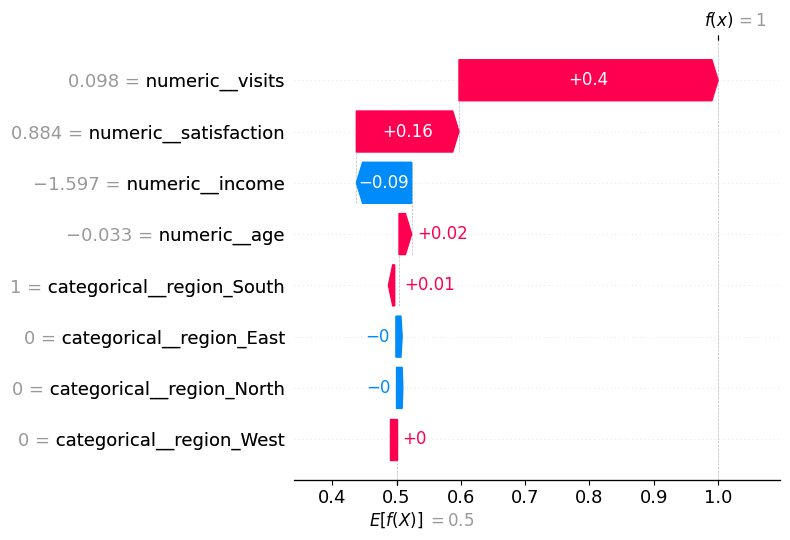

In [14]:
# Local Waterfall Chart

local_explanation = shap.Explanation(
    values=local_shap_values,
    base_values=class_one_expected_value,
    data=X_test_explain.iloc[
        ROW_TO_EXPLAIN
    ].values,
    feature_names=(
        transformed_feature_names.tolist()
    ),
)

plt.figure(figsize=(10, 7))

shap.plots.waterfall(
    local_explanation,
    max_display=10,
    show=False,
)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "shap_local_waterfall.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [15]:
# GEnerate Explanations for every test row

explanation_rows = []

calibrated_predictions = (
    calibrated_model.predict(X_test)
)

calibrated_probabilities = (
    calibrated_model.predict_proba(
        X_test
    )[:, 1]
)

for row_position in range(len(X_test)):
    row_shap_values = (
        class_one_shap_values[row_position]
    )

    highest_positive_index = int(
        np.argmax(row_shap_values)
    )

    highest_negative_index = int(
        np.argmin(row_shap_values)
    )

    positive_feature = (
        transformed_feature_names[
            highest_positive_index
        ]
    )

    negative_feature = (
        transformed_feature_names[
            highest_negative_index
        ]
    )

    explanation_rows.append({
        "row_number": row_position,
        "actual": y_test.iloc[row_position],
        "prediction":
            calibrated_predictions[
                row_position
            ],
        "probability_class_1":
            calibrated_probabilities[
                row_position
            ],
        "strongest_positive_feature":
            positive_feature,
        "strongest_positive_effect":
            row_shap_values[
                highest_positive_index
            ],
        "strongest_negative_feature":
            negative_feature,
        "strongest_negative_effect":
            row_shap_values[
                highest_negative_index
            ],
    })

individual_explanations_df = pd.DataFrame(
    explanation_rows
)

display(
    individual_explanations_df.head(10)
)

,row_number,actual,prediction,probability_class_1,strongest_positive_feature,strongest_positive_effect,strongest_negative_feature,strongest_negative_effect
0,0,1,1,0.882422,numeric__visits,0.402909,numeric__income,-0.086033
1,1,1,0,0.433327,numeric__visits,0.184285,numeric__income,-0.278684
2,2,1,1,0.882422,numeric__satisfaction,0.399888,numeric__visits,-0.159624
3,3,0,0,0.433219,numeric__income,0.154782,numeric__visits,-0.363030
4,4,0,0,0.352190,categorical__region_South,0.018257,numeric__visits,-0.212384
5,5,1,1,0.882422,numeric__income,0.323703,numeric__satisfaction,-0.056650
6,6,0,0,0.277685,numeric__income,0.039486,numeric__visits,-0.297470
7,7,1,1,0.882422,numeric__visits,0.424713,numeric__satisfaction,-0.076479
8,8,1,1,0.882422,numeric__satisfaction,0.205880,categorical__region_East,-0.001934
9,9,1,1,0.882422,numeric__visits,0.340070,numeric__satisfaction,-0.058217


In [16]:
# Extract Decision Tree rules

decision_tree_rules = export_text(
    tree_model,
    feature_names=list(
        transformed_feature_names
    ),
    max_depth=tree_model.get_depth(),
)

print(decision_tree_rules[:10000])

|--- numeric__income <= -0.40
|   |--- numeric__visits <= 0.01
|   |   |--- numeric__satisfaction <= 0.55
|   |   |   |--- class: 0
|   |   |--- numeric__satisfaction >  0.55
|   |   |   |--- numeric__income <= -1.32
|   |   |   |   |--- numeric__visits <= -0.16
|   |   |   |   |   |--- numeric__income <= -1.52
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- numeric__income >  -1.52
|   |   |   |   |   |   |--- numeric__age <= 0.07
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- numeric__age >  0.07
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- numeric__visits >  -0.16
|   |   |   |   |   |--- class: 1
|   |   |   |--- numeric__income >  -1.32
|   |   |   |   |--- categorical__region_North <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- categorical__region_North >  0.50
|   |   |   |   |   |--- class: 0
|   |--- numeric__visits >  0.01
|   |   |--- numeric__satisfaction <= 0.42
|   |   |   |--- numeric__visits <= 0.5

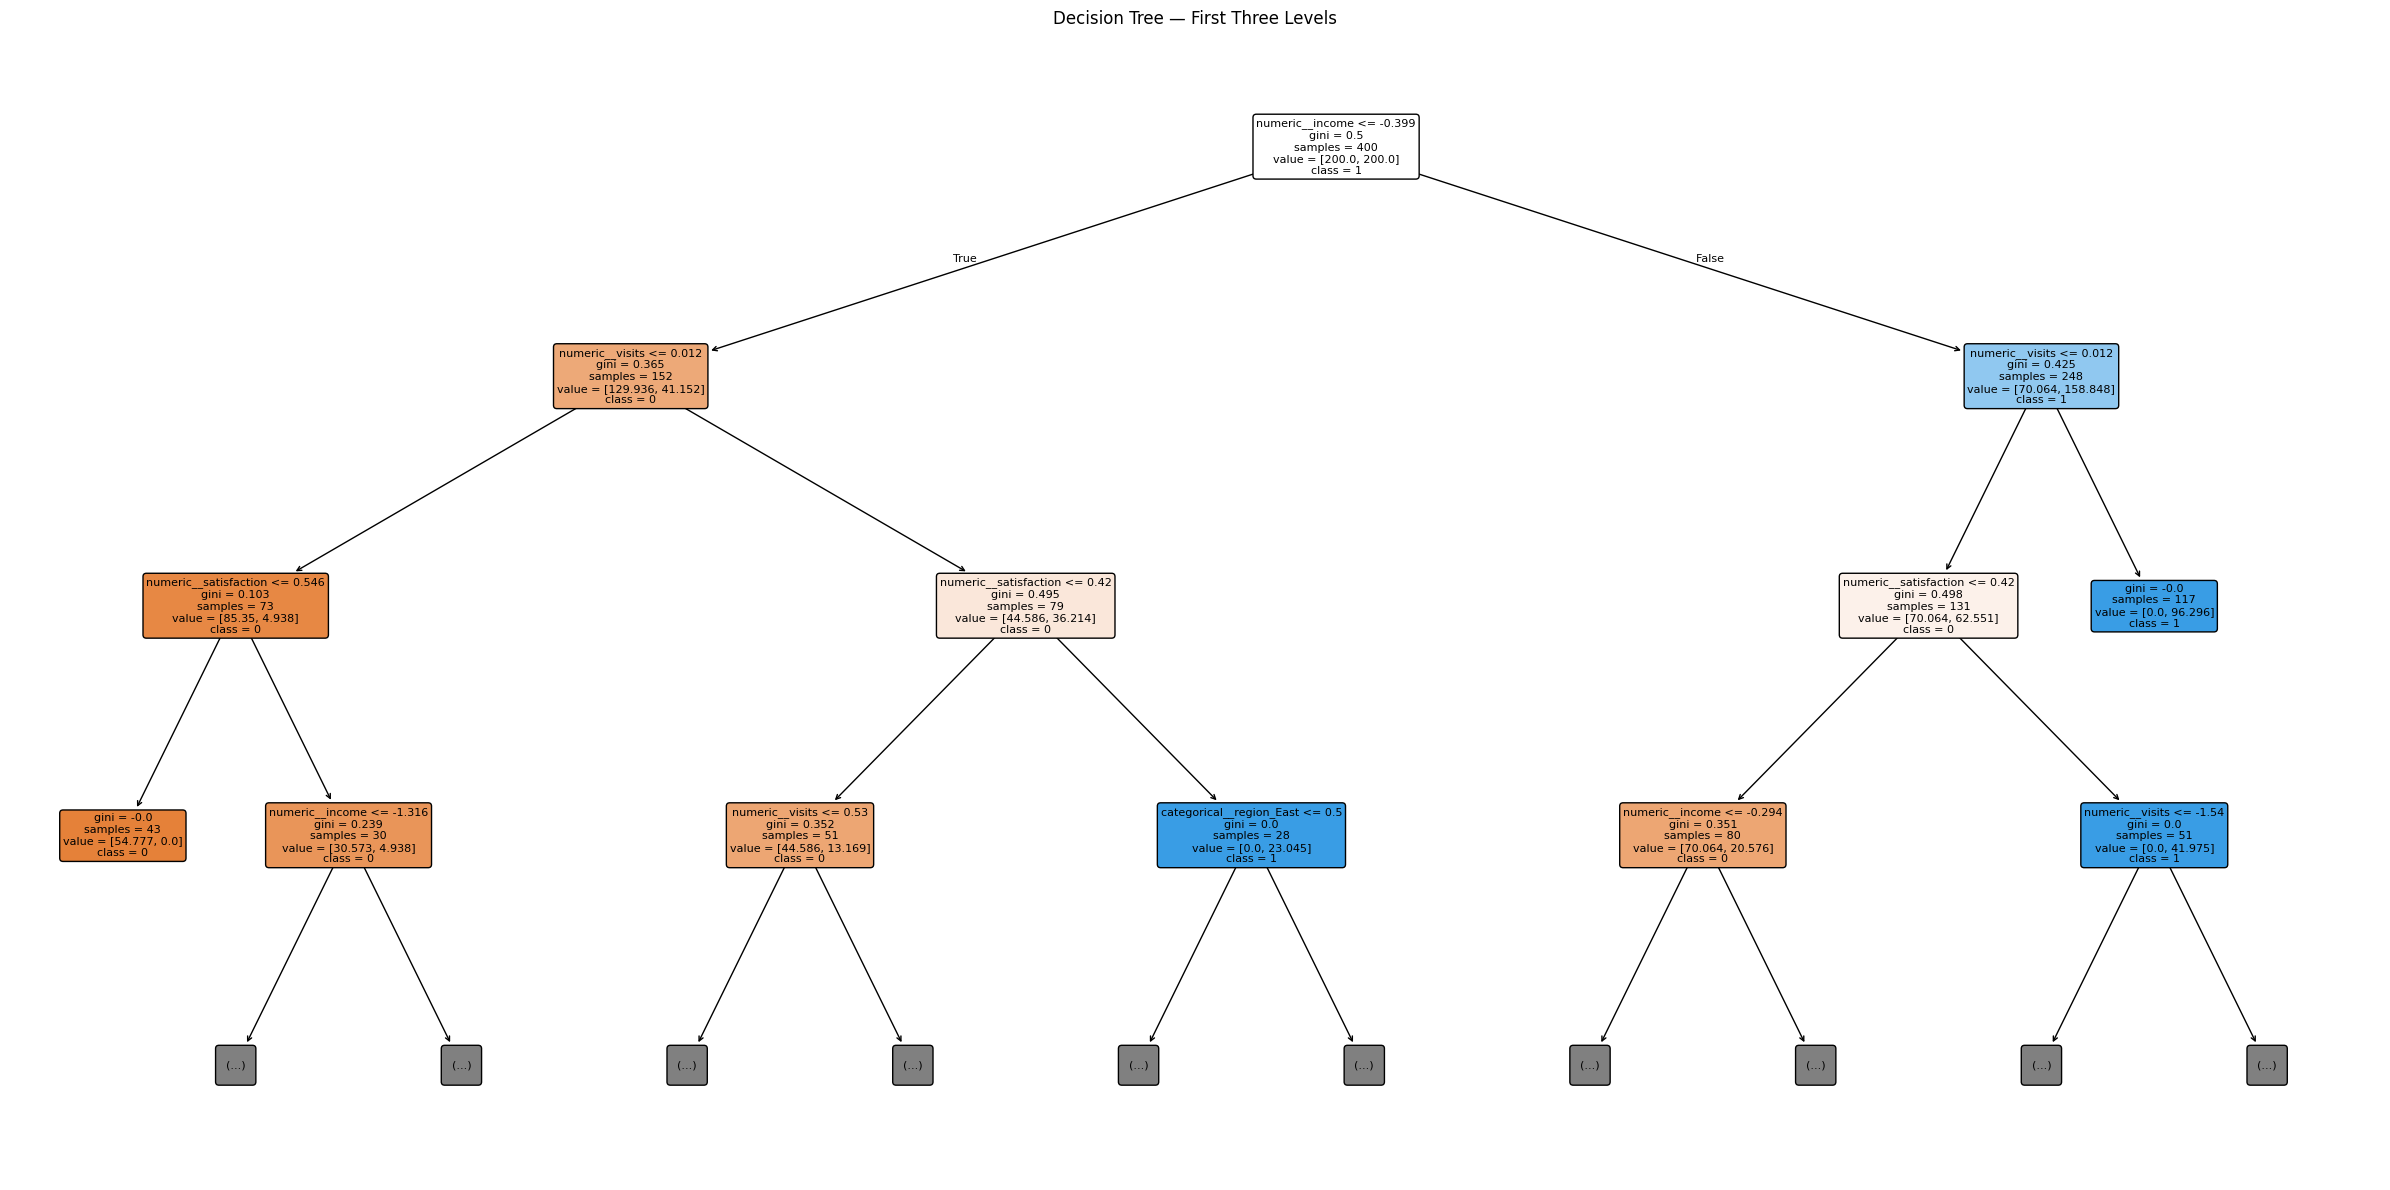

In [17]:
# Decision Tree Visuvalization

plt.figure(figsize=(24, 12))

plot_tree(
    tree_model,
    feature_names=transformed_feature_names,
    class_names=[
        str(value)
        for value in tree_model.classes_
    ],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)

plt.title(
    "Decision Tree — First Three Levels"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "decision_tree_top_levels.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

income          float64
visits          float64
satisfaction    float64
age             float64
dtype: object


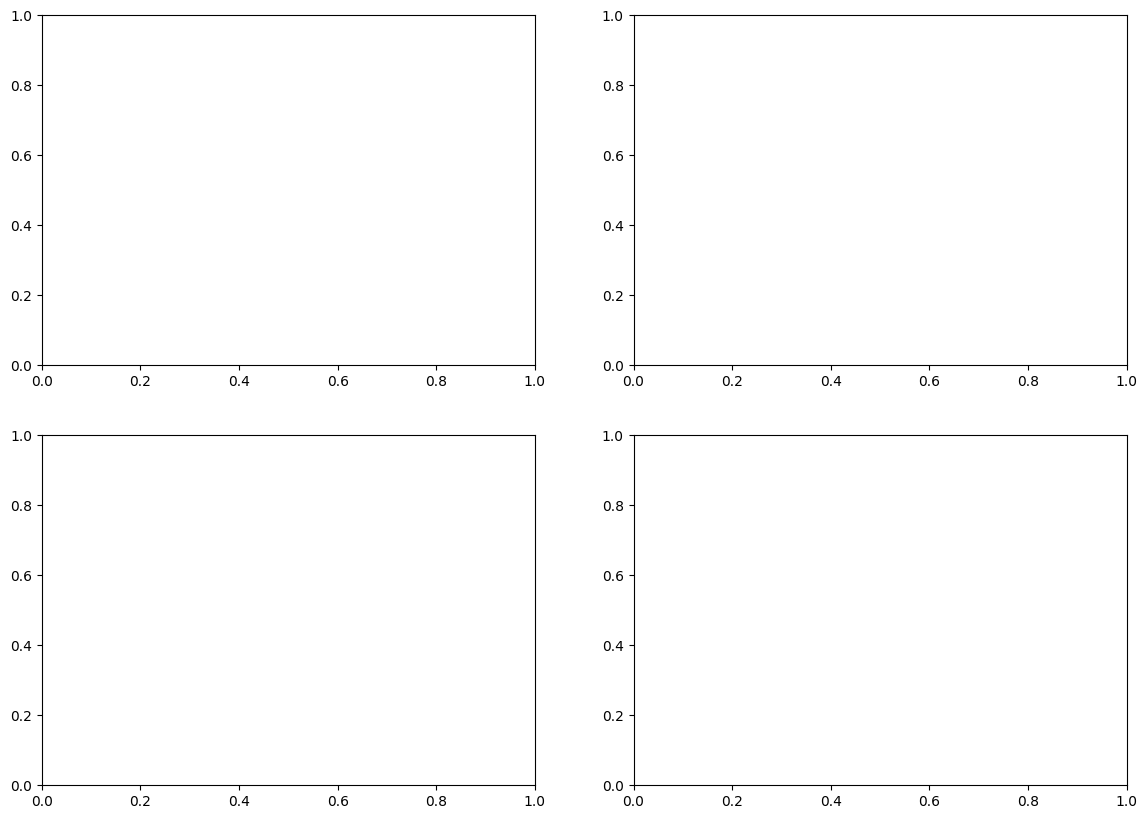

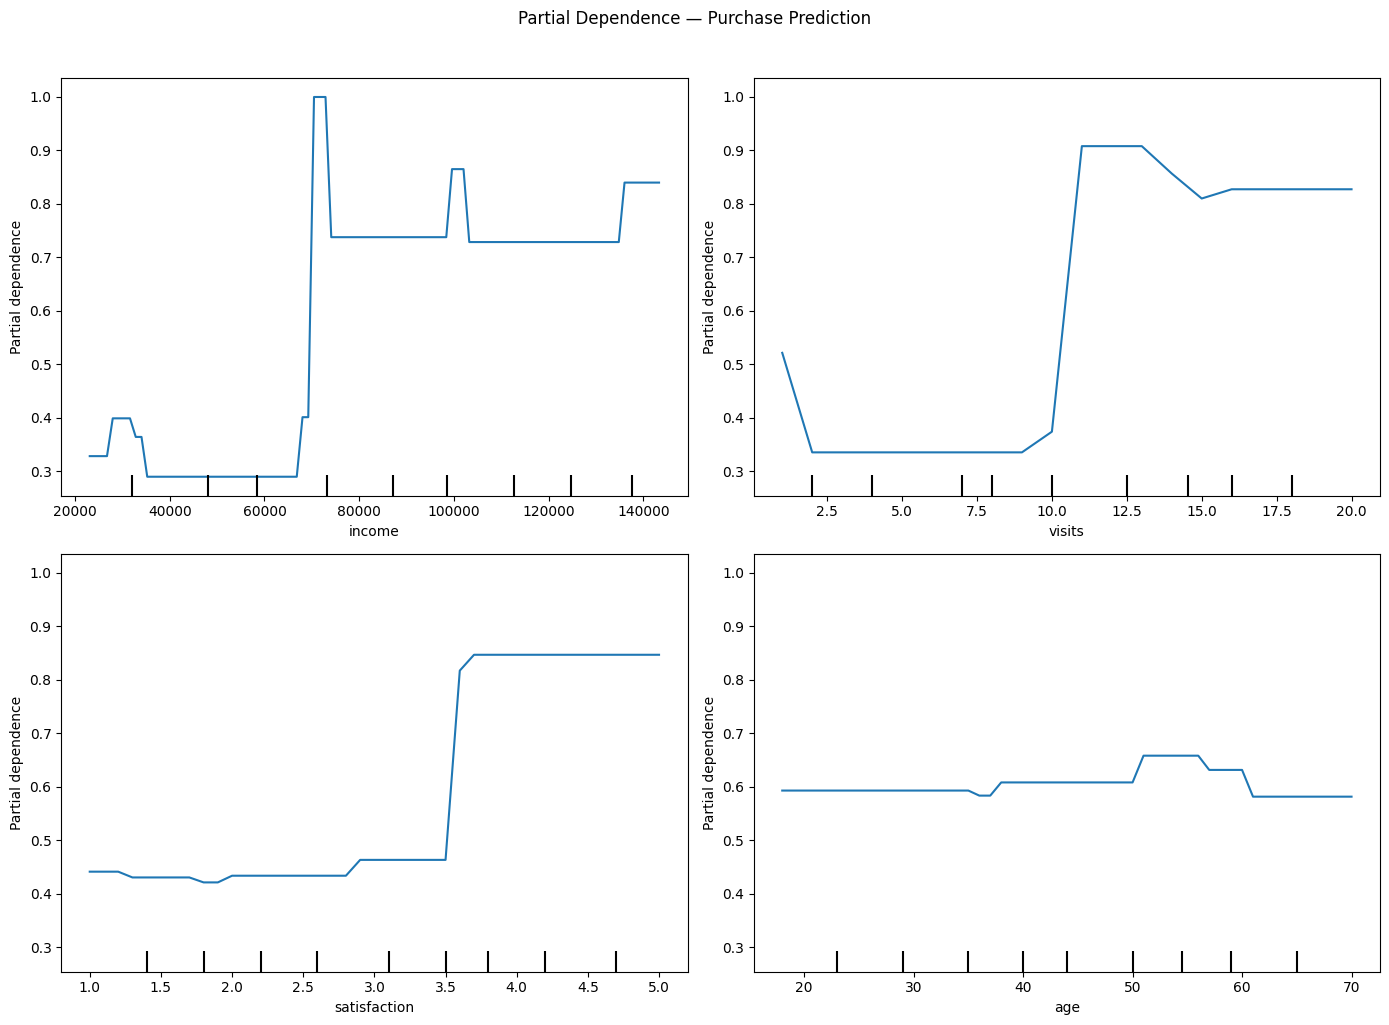

In [19]:



# Create a separate copy for partial dependence.
X_partial_dependence = X_train.copy()

partial_dependence_features = [
    column
    for column in [
        "income",
        "visits",
        "satisfaction",
        "age",
    ]
    if column in X_partial_dependence.columns
]

# Partial dependence requires numerical columns
# to use floating-point dtypes.
for column in partial_dependence_features:
    X_partial_dependence[column] = (
        pd.to_numeric(
            X_partial_dependence[column],
            errors="coerce",
        ).astype(float)
    )

print(
    X_partial_dependence[
        partial_dependence_features
    ].dtypes
)

number_of_features = len(
    partial_dependence_features
)

number_of_columns = 2

number_of_rows = int(
    np.ceil(
        number_of_features
        / number_of_columns
    )
)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(14, 5 * number_of_rows),
)

axes = np.asarray(axes).reshape(-1)

PartialDependenceDisplay.from_estimator(
    estimator=base_model,
    X=X_partial_dependence,
    features=partial_dependence_features,
    method="brute",
    n_jobs=-1,
    ax=axes[:number_of_features],
)

# Hide unused chart areas.
for axis in axes[number_of_features:]:
    axis.set_visible(False)

plt.suptitle(
    "Partial Dependence — Purchase Prediction",
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "partial_dependence.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [20]:
# Automation explanation Summary

top_grouped_features = (
    grouped_shap_df.head(3)[
        "original_feature"
    ].tolist()
)

top_permutation_features = (
    permutation_importance_df.head(3)[
        "feature"
    ].tolist()
)

explanation_summary = {
    "prediction_model":
        "final_calibrated_model.joblib",
    "shap_explanation_model":
        "final_selected_model.joblib",
    "base_algorithm":
        type(tree_model).__name__,
    "tree_depth": int(
        tree_model.get_depth()
    ),
    "tree_leaves": int(
        tree_model.get_n_leaves()
    ),
    "top_shap_features":
        top_grouped_features,
    "top_permutation_features":
        top_permutation_features,
    "important_note": (
        "SHAP values explain the uncalibrated "
        "base Decision Tree. Final probabilities "
        "come from the sigmoid-calibrated model."
    ),
}

print(json.dumps(
    explanation_summary,
    indent=4,
))

{
    "prediction_model": "final_calibrated_model.joblib",
    "shap_explanation_model": "final_selected_model.joblib",
    "base_algorithm": "DecisionTreeClassifier",
    "tree_depth": 8,
    "tree_leaves": 40,
    "top_shap_features": [
        "visits",
        "income",
        "satisfaction"
    ],
    "top_permutation_features": [
        "satisfaction",
        "income",
        "visits"
    ],
    "important_note": "SHAP values explain the uncalibrated base Decision Tree. Final probabilities come from the sigmoid-calibrated model."
}


In [21]:
# Save explainability outputs

tree_importance_df.to_csv(
    EXPLAIN_DIR / "tree_feature_importance.csv",
    index=False,
)

global_shap_df.to_csv(
    EXPLAIN_DIR / "global_shap_importance.csv",
    index=False,
)

grouped_shap_df.to_csv(
    EXPLAIN_DIR / "grouped_shap_importance.csv",
    index=False,
)

permutation_importance_df.to_csv(
    EXPLAIN_DIR / "permutation_importance.csv",
    index=False,
)

individual_explanations_df.to_csv(
    EXPLAIN_DIR / "individual_explanations.csv",
    index=False,
)

local_explanation_df.to_csv(
    EXPLAIN_DIR / "sample_local_explanation.csv",
    index=False,
)

with open(
    EXPLAIN_DIR / "decision_tree_rules.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(decision_tree_rules)

with open(
    EXPLAIN_DIR / "explanation_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        explanation_summary,
        file,
        indent=4,
    )

print("Explainability outputs saved.")

Explainability outputs saved.


In [22]:
# Verify outputs

required_files = [
    "tree_feature_importance.csv",
    "global_shap_importance.csv",
    "grouped_shap_importance.csv",
    "permutation_importance.csv",
    "individual_explanations.csv",
    "sample_local_explanation.csv",
    "decision_tree_rules.txt",
    "explanation_summary.json",
]

for filename in required_files:
    path = EXPLAIN_DIR / filename
    print(f"{filename}: {path.exists()}")

tree_feature_importance.csv: True
global_shap_importance.csv: True
grouped_shap_importance.csv: True
permutation_importance.csv: True
individual_explanations.csv: True
sample_local_explanation.csv: True
decision_tree_rules.txt: True
explanation_summary.json: True
